# Phase 3: Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to explore the cleaned book dataset and identify important patterns, distributions, relationships, and trends in book prices, ratings, stock availability, categories, and description length.

The analysis includes:
- Dataset overview and summary statistics
- Categorical and numerical analysis
- Price and rating distributions
- Price comparison by rating and category
- Relationship between price and rating
- Correlation analysis and heatmap
- Outlier detection using boxplot
- Category-level analysis
- Stock analysis
- Description length analysis
- Key findings and business insights

## 1. Loading the Cleaned Dataset

The cleaned dataset generated during Phase 2 is loaded for exploratory analysis.

The dataset contains 1,000 books with information such as price, rating, category, stock count, tax, and description length.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_books_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 13)


,title,price,rating,availability,product_url,category,upc,stock_count,tax,description,price_category,rating_category,description_length
0,A Light in the Attic,51.77,3,In Stock,https://books.toscrape.com/catalogue/a-light-i...,Poetry,a897fe39b1053632,22,0.0,It's hard to imagine a world without A Light i...,Premium,Average Rated,1017
1,Tipping the Velvet,53.74,1,In Stock,https://books.toscrape.com/catalogue/tipping-t...,Historical Fiction,90fa61229261140a,20,0.0,"""Erotic and absorbing...Written with starling ...",Premium,Low Rated,1029
2,Soumission,50.10,1,In Stock,https://books.toscrape.com/catalogue/soumissio...,Fiction,6957f44c3847a760,20,0.0,"Dans une France assez proche de la nÃ´tre, un ...",Premium,Low Rated,1136
3,Sharp Objects,47.82,4,In Stock,https://books.toscrape.com/catalogue/sharp-obj...,Mystery,e00eb4fd7b871a48,20,0.0,"WICKED above her hipbone, GIRL across her hear...",Premium,Highly Rated,1647
4,Sapiens: A Brief History of Humankind,54.23,5,In Stock,https://books.toscrape.com/catalogue/sapiens-a...,History,4165285e1663650f,20,0.0,From a renowned historian comes a groundbreaki...,Premium,Highly Rated,1969


## 2. Summary Statistics

Descriptive statistics are generated for the numerical variables to understand their central tendency, spread, minimum, maximum, and overall distribution.

In [2]:
df.describe()

,price,rating,stock_count,tax,description_length
count,1000.00000,1000.000000,1000.000000,1000.0,1000.000000
mean,35.07035,2.923000,8.585000,0.0,1441.497000
std,14.44669,1.434967,5.654622,0.0,676.398586
min,10.00000,1.000000,1.000000,0.0,24.000000
25%,22.10750,2.000000,3.000000,0.0,1074.750000
50%,35.98000,3.000000,7.000000,0.0,1353.500000
75%,47.45750,4.000000,14.000000,0.0,1696.500000
max,59.99000,5.000000,22.000000,0.0,8646.000000


## 3. Dataset Overview and Category Distribution

The dataset is further explored by examining the number of unique book categories and the distribution of books across ratings and price categories.

This helps identify the overall structure of the catalogue and the distribution of books across important segments.

In [3]:
print("Number of categories:", df["category"].nunique())

print("\nBooks by rating:")
print(df["rating"].value_counts().sort_index())

print("\nBooks by price category:")
print(df["price_category"].value_counts())

print("\nBooks by rating category:")
print(df["rating_category"].value_counts())

Number of categories: 50

Books by rating:
rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

Books by price category:
price_category
Premium      403
Mid-Range    401
Budget       196
Name: count, dtype: int64

Books by rating category:
rating_category
Low Rated        422
Highly Rated     375
Average Rated    203
Name: count, dtype: int64


## 4. Distribution of Book Prices

A histogram is used to examine the distribution of book prices.

This helps identify the most common price ranges and understand how prices are distributed across the catalogue.

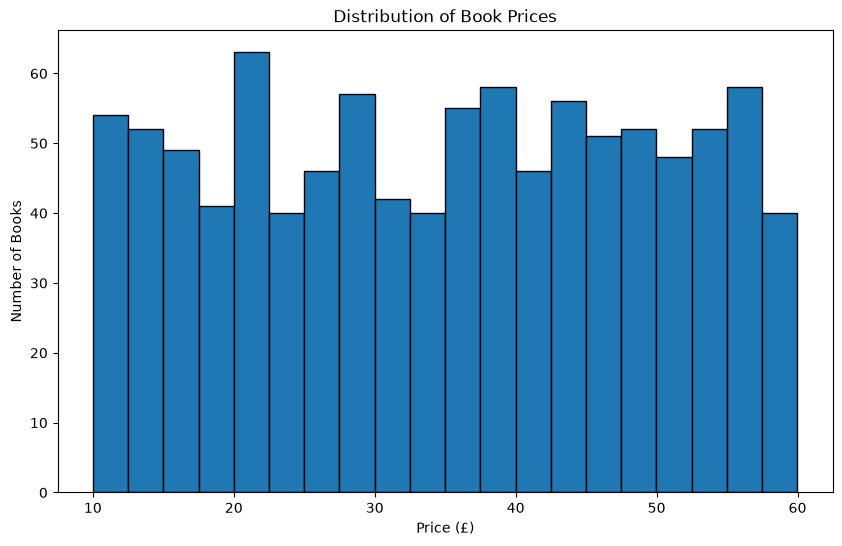

In [4]:
plt.figure(figsize=(10, 6))

plt.hist(df["price"], bins=20, edgecolor="black")

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

## 5. Distribution of Book Ratings

A bar chart is used to examine how many books received each rating from 1 to 5.

This provides an overview of the rating distribution within the dataset.

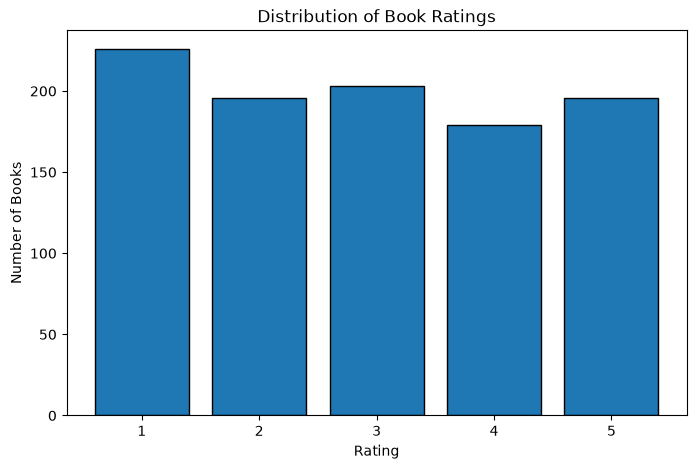

In [5]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index, rating_counts.values, edgecolor="black")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

## 6. Distribution of Price Categories

The distribution of Budget, Mid-Range, and Premium books is visualized.

This helps understand how the catalogue is divided into different price segments.

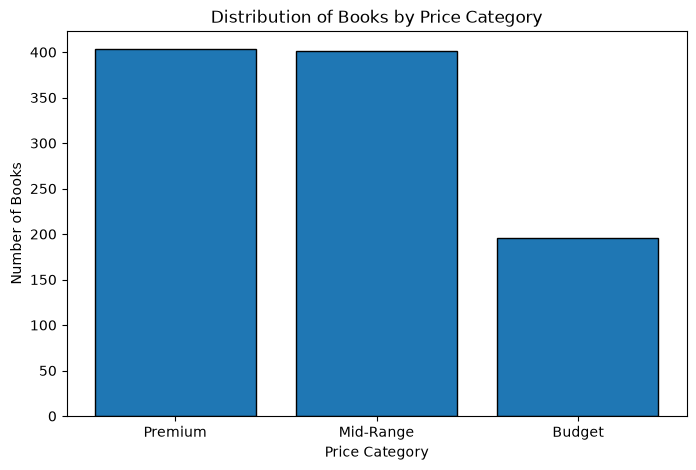

In [6]:
price_counts = df["price_category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(price_counts.index, price_counts.values, edgecolor="black")

plt.title("Distribution of Books by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")

plt.show()

## 7. Average Book Price by Rating

The average price of books is calculated for each rating level.

This analysis helps determine whether books with higher ratings tend to have noticeably different prices.

In [7]:
avg_price_by_rating = df.groupby("rating")["price"].mean()

print(avg_price_by_rating)

rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price, dtype: float64


## 8. Visualizing Average Price by Rating

A bar chart is created to compare the average book price across different rating levels.

The visualization makes it easier to identify differences in average prices between rating groups.

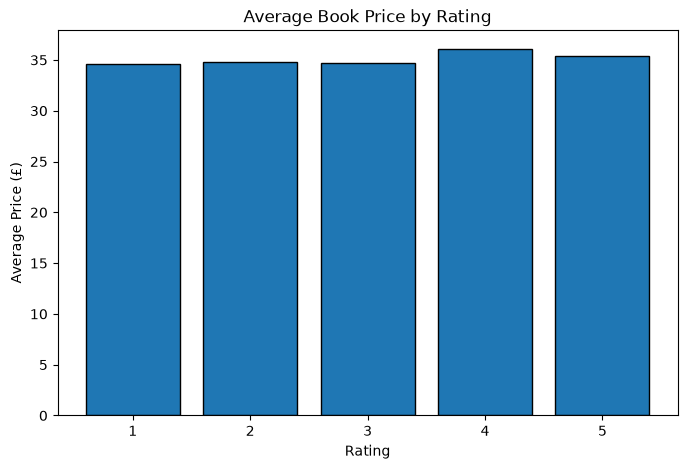

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_by_rating.index,
    avg_price_by_rating.values,
    edgecolor="black"
)

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

## 9. Average Book Price by Category

The average price is calculated for each book category and sorted in descending order.

The top 10 categories with the highest average prices are selected for further visualization.

In [9]:
avg_price_by_category = (
    df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_by_category.head(10))


category
Suspense            58.330000
Novels              54.810000
Politics            53.613333
Health              51.452500
New Adult           46.383333
Christian           42.496667
Sports and Games    41.166000
Self Help           40.620000
Travel              39.794545
Fantasy             39.593958
Name: price, dtype: float64


## 10. Top 10 Categories by Average Price

A horizontal bar chart is used to visualize the top 10 book categories based on their average price.

This highlights which categories have the highest average catalogue prices.

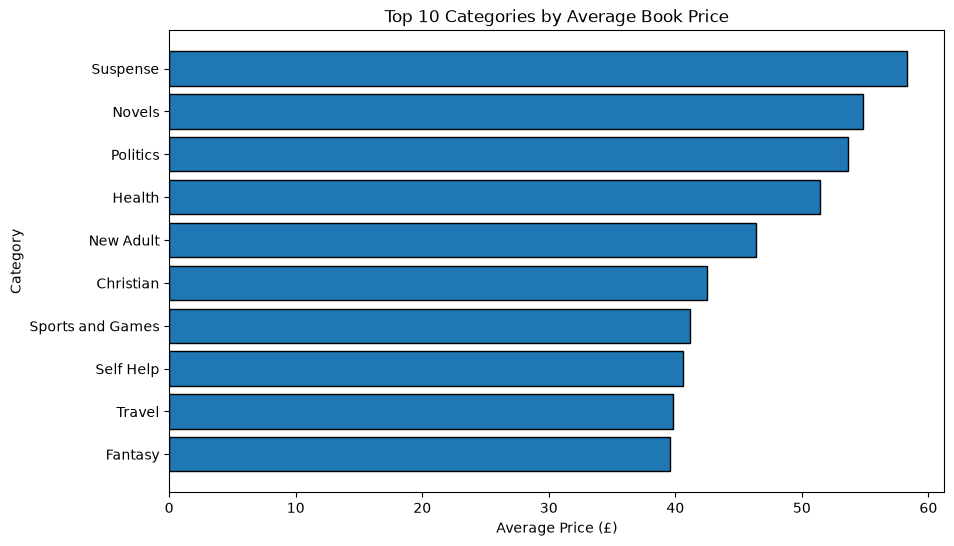

In [10]:
top_10_categories = avg_price_by_category.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_categories.index[::-1],
    top_10_categories.values[::-1],
    edgecolor="black"
)

plt.title("Top 10 Categories by Average Book Price")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.show()

## 11. Relationship Between Book Price and Rating

A scatter plot is used to examine the relationship between book price and rating.

This helps determine whether higher-priced books tend to receive higher ratings.

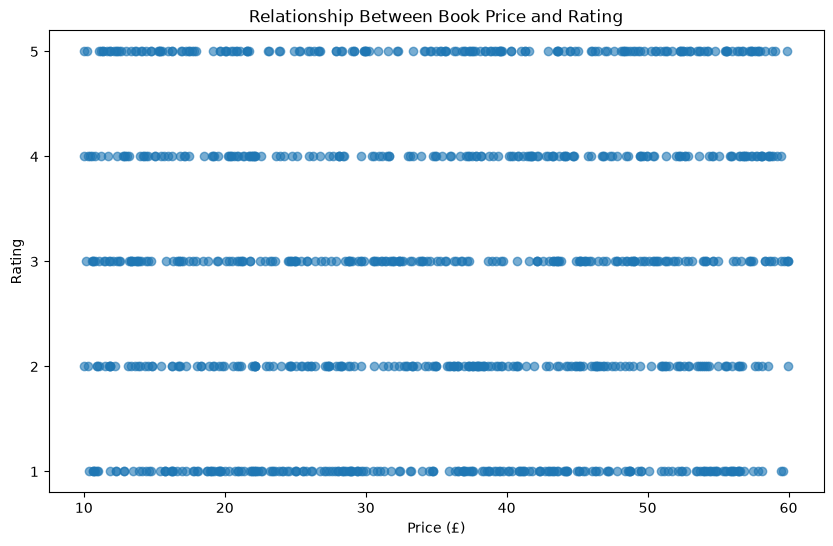

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["price"],
    df["rating"],
    alpha=0.6
)

plt.title("Relationship Between Book Price and Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.yticks([1, 2, 3, 4, 5])

plt.show()

## 12. Correlation Analysis

Correlation coefficients are calculated between the main numerical variables, including price, rating, stock count, tax, and description length.

Correlation analysis helps identify the strength and direction of relationships between numerical features.

In [12]:
correlation = df[
    ["price", "rating", "stock_count", "tax", "description_length"]
].corr()

print(correlation)

                       price    rating  stock_count  tax  description_length
price               1.000000  0.028166    -0.010914  NaN            0.021607
rating              0.028166  1.000000     0.016166  NaN            0.024902
stock_count        -0.010914  0.016166     1.000000  NaN            0.055955
tax                      NaN       NaN          NaN  NaN                 NaN
description_length  0.021607  0.024902     0.055955  NaN            1.000000


## 13. Correlation Heatmap

A correlation heatmap is created to visually represent the relationships between numerical variables.

The heatmap makes it easier to identify strong, weak, positive, or negative correlations.

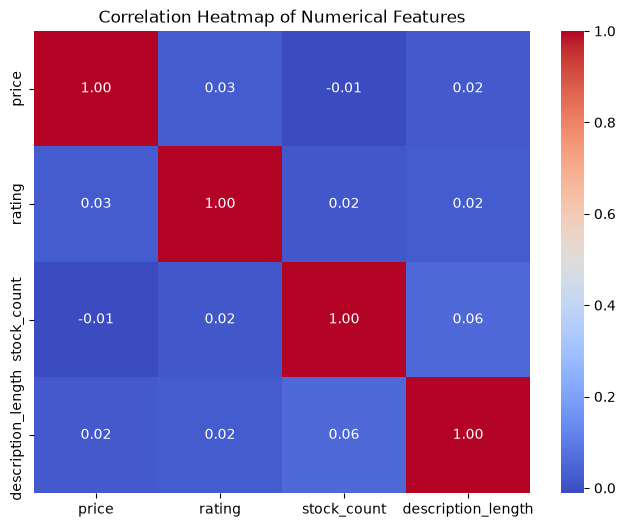

In [13]:
corr_for_heatmap = df[
    ["price", "rating", "stock_count", "description_length"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_for_heatmap,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

## 14. Price Outlier Analysis

A boxplot is used to examine the distribution of book prices and identify potential outliers.

This provides a visual understanding of the minimum, median, spread, and extreme price values.

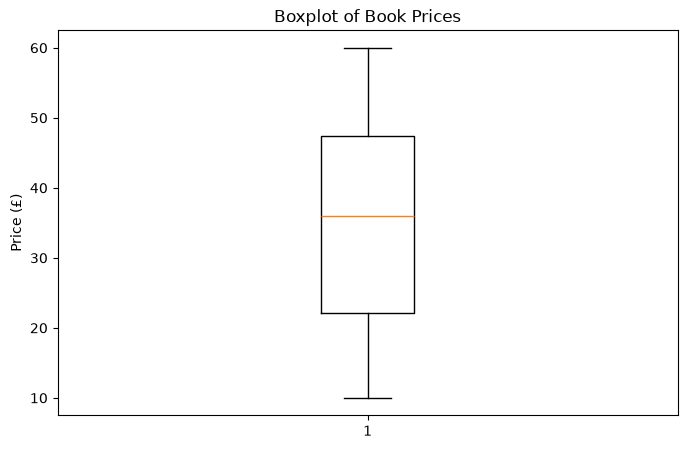

In [14]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["price"])

plt.title("Boxplot of Book Prices")
plt.ylabel("Price (£)")

plt.show()

## 15. Average Rating by Category

The average rating is calculated for each book category and sorted from highest to lowest.

The top 10 categories are selected to identify categories with the highest average ratings.

In [15]:
avg_rating_by_category = (
    df.groupby("category")["rating"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_rating_by_category.head(10))

category
Erotica              5.000000
Adult Fiction        5.000000
Novels               5.000000
Christian Fiction    4.166667
Health               3.750000
Art                  3.625000
Poetry               3.526316
Humor                3.400000
Spirituality         3.333333
Young Adult          3.296296
Name: rating, dtype: float64


## 16. Top 10 Categories by Average Rating

A horizontal bar chart is used to visualize the top 10 categories based on their average rating.

This helps compare rating performance across different categories.

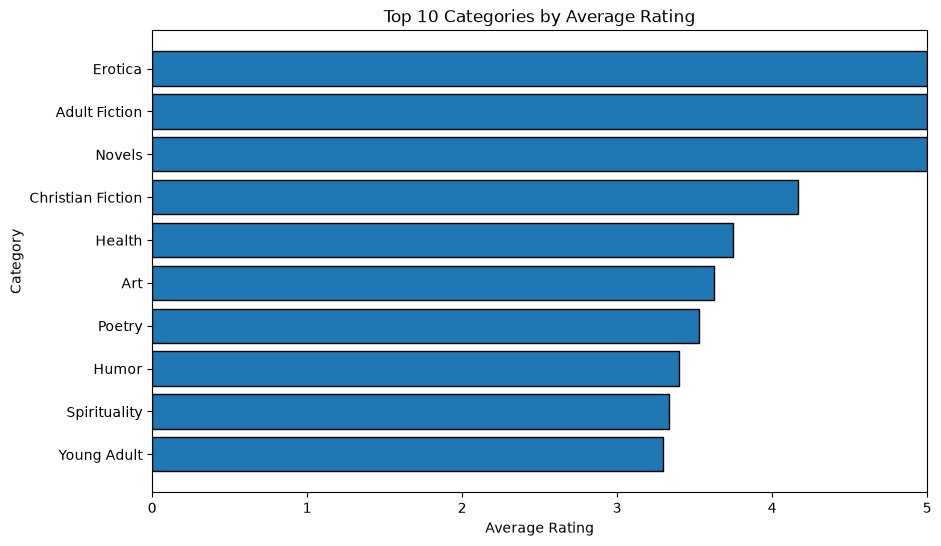

In [16]:
top_10_rating_categories = avg_rating_by_category.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_rating_categories.index[::-1],
    top_10_rating_categories.values[::-1],
    edgecolor="black"
)

plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.xlim(0, 5)

plt.show()

## 17. Category Popularity

The number of books in each category is calculated.

The top 10 categories by number of books are selected to understand which categories are most represented in the catalogue.

In [17]:
category_counts = df["category"].value_counts().head(10)

print(category_counts)

category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64


## 18. Top 10 Categories by Number of Books

A horizontal bar chart is used to visualize the 10 categories containing the largest number of books.

This provides an overview of the most frequently represented categories in the dataset.

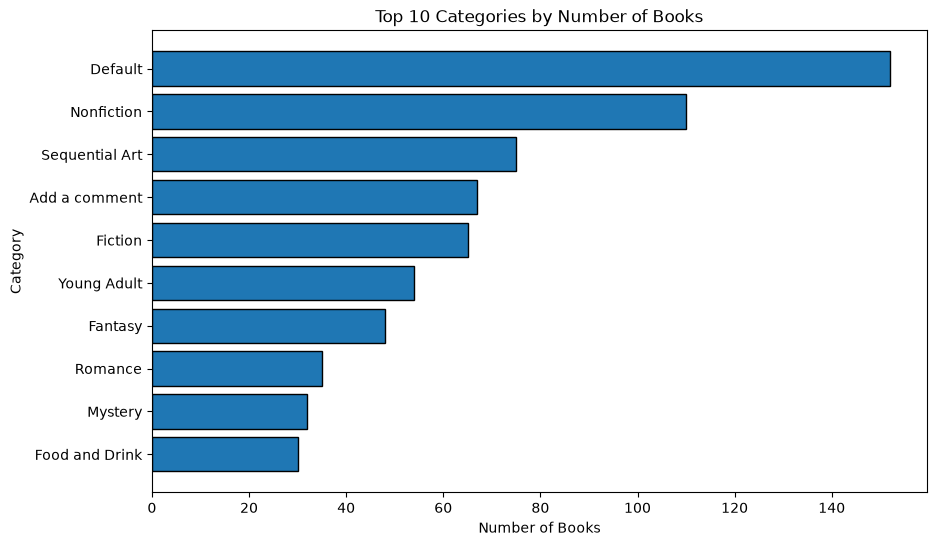

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_counts.index[::-1],
    category_counts.values[::-1],
    edgecolor="black"
)

plt.title("Top 10 Categories by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Category")

plt.show()

## 19. Average Stock Count by Rating

The average stock count is calculated for each rating level.

This analysis explores whether books with different ratings have noticeably different average stock availability.

In [19]:
avg_stock_by_rating = (
    df.groupby("rating")["stock_count"]
    .mean()
)

print(avg_stock_by_rating)

rating
1    8.362832
2    8.765306
3    8.364532
4    8.882682
5    8.617347
Name: stock_count, dtype: float64


## 20. Visualizing Average Stock by Rating

A bar chart is used to compare the average stock count across the five rating levels.

This helps identify any visible differences in stock availability between rating groups.

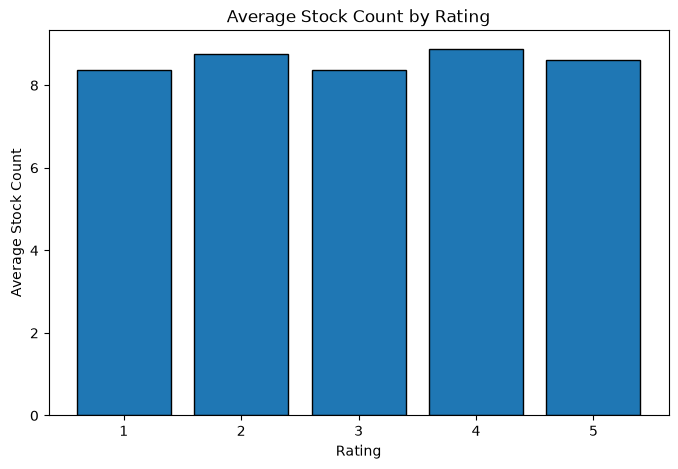

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_stock_by_rating.index,
    avg_stock_by_rating.values,
    edgecolor="black"
)

plt.title("Average Stock Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Stock Count")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

## 21. Average Price by Price Category

The average price is calculated for each price category: Budget, Mid-Range, and Premium.

This provides a numerical comparison of the three price segments.

In [21]:
avg_price_by_price_category = (
    df.groupby("price_category")["price"]
    .mean()
)

print(avg_price_by_price_category)

price_category
Budget       14.798571
Mid-Range    30.063067
Premium      49.912010
Name: price, dtype: float64


## 22. Visualizing Average Price by Price Category

A bar chart is used to compare the average price of Budget, Mid-Range, and Premium books.

The visualization clearly shows the difference in average price between the three segments.

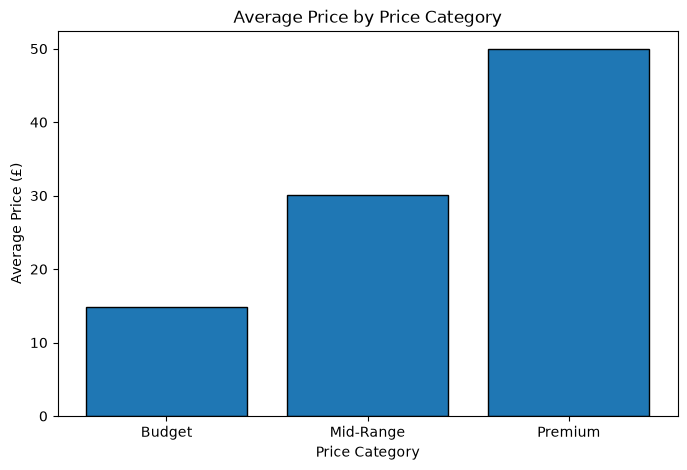

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_by_price_category.index,
    avg_price_by_price_category.values,
    edgecolor="black"
)

plt.title("Average Price by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Average Price (£)")

plt.show()

## 23. Average Description Length by Rating

The average description length is calculated for each rating level.

This analysis explores whether books with different ratings have noticeably different description lengths.

In [23]:
avg_description_by_rating = (
    df.groupby("rating")["description_length"]
    .mean()
)

print(avg_description_by_rating)

rating
1    1470.039823
2    1380.403061
3    1440.990148
4    1364.290503
5    1540.714286
Name: description_length, dtype: float64


## 24. Visualizing Average Description Length by Rating

A bar chart is used to compare the average description length across different rating levels.

This helps identify whether any noticeable pattern exists between rating and description length.

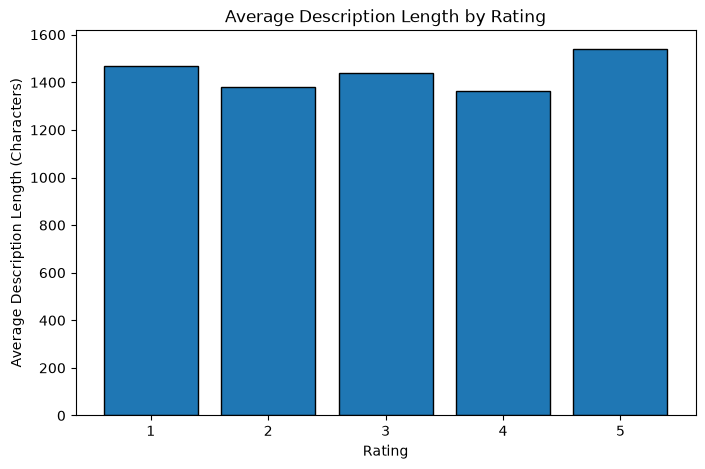

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_description_by_rating.index,
    avg_description_by_rating.values,
    edgecolor="black"
)

plt.title("Average Description Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Description Length (Characters)")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [25]:
print("KEY EDA FINDINGS")
print("-" * 40)

print(f"Average book price: £{df['price'].mean():.2f}")
print(f"Average rating: {df['rating'].mean():.2f}")
print(f"Average stock count: {df['stock_count'].mean():.2f}")
print(f"Average description length: {df['description_length'].mean():.2f} characters")

print(f"\nMost common category: {df['category'].value_counts().idxmax()}")
print(f"Number of categories: {df['category'].nunique()}")

print(f"\nHighest average price category: {avg_price_by_category.idxmax()}")
print(f"Highest average price: £{avg_price_by_category.max():.2f}")

print(f"\nHighest average rating category: {avg_rating_by_category.idxmax()}")
print(f"Highest average rating: {avg_rating_by_category.max():.2f}")

print(f"\nHighest average stock by rating: {avg_stock_by_rating.idxmax()} stars")
print(f"Highest average stock: {avg_stock_by_rating.max():.2f}")

KEY EDA FINDINGS
----------------------------------------
Average book price: £35.07
Average rating: 2.92
Average stock count: 8.59
Average description length: 1441.50 characters

Most common category: Default
Number of categories: 50

Highest average price category: Suspense
Highest average price: £58.33

Highest average rating category: Erotica
Highest average rating: 5.00

Highest average stock by rating: 4 stars
Highest average stock: 8.88


# 25. Key EDA Findings

The main findings from the exploratory data analysis are summarized below.

- The dataset contains 1,000 books across 50 categories.
- The average book price is approximately £35.07.
- Book prices range from approximately £10.00 to £59.99.
- The average book rating is approximately 2.92 out of 5.
- The average stock count is approximately 8.59 books.
- The average description length is approximately 1,441 characters.
- Premium books have a substantially higher average price than Budget and Mid-Range books.
- Suspense has the highest average book price among the analysed categories.
- The relationship between book price and rating is very weak.
- The correlation analysis shows generally weak relationships between the numerical variables.
- The price distribution does not show major extreme outliers.
- Some categories have high average ratings, but these results should be interpreted carefully because some categories contain relatively few books.
- There is no meaningful time-based trend analysis because the dataset does not contain a date or time field.

Overall, the EDA provides useful insights into catalogue pricing, ratings, categories, stock levels, and book descriptions and prepares the dataset for the Machine Learning phase.